In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
#Load & Exploratory Data Analysis (EDA)
#buat ngeliat isi dataset dah masuk, bisa ngebaca apa blom. trus ada juga yg buat nentuin range fuzzy yg dipake

In [3]:
data_mobil = pd.read_csv("data/merc.csv")

In [4]:
data_mobil.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,SLK,2005,5200,Automatic,63000,Petrol,325,32.1,1.8
1,S Class,2017,34948,Automatic,27000,Hybrid,20,61.4,2.1
2,SL CLASS,2016,49948,Automatic,6200,Petrol,555,28.0,5.5
3,G Class,2016,61948,Automatic,16000,Petrol,325,30.4,4.0
4,G Class,2016,73948,Automatic,4000,Petrol,325,30.1,4.0


In [5]:
data_mobil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13119 entries, 0 to 13118
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         13119 non-null  object 
 1   year          13119 non-null  int64  
 2   price         13119 non-null  int64  
 3   transmission  13119 non-null  object 
 4   mileage       13119 non-null  int64  
 5   fuelType      13119 non-null  object 
 6   tax           13119 non-null  int64  
 7   mpg           13119 non-null  float64
 8   engineSize    13119 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 922.6+ KB


In [6]:
data_mobil.describe()

,year,price,mileage,tax,mpg,engineSize
count,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000
mean,2017.296288,24698.596920,21949.559037,129.972178,55.155843,2.071530
std,2.224709,11842.675542,21176.512267,65.260286,15.220082,0.572426
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17450.000000,6097.500000,125.000000,45.600000,1.800000
50%,2018.000000,22480.000000,15189.000000,145.000000,56.500000,2.000000
75%,2019.000000,28980.000000,31779.500000,145.000000,64.200000,2.100000
max,2020.000000,159999.000000,259000.000000,580.000000,217.300000,6.200000


In [7]:
data_mobil = data_mobil[['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']]

In [8]:
data_mobil.head()

,year,mileage,tax,mpg,engineSize,price
0,2005,63000,325,32.1,1.8,5200
1,2017,27000,20,61.4,2.1,34948
2,2016,6200,555,28.0,5.5,49948
3,2016,16000,325,30.4,4.0,61948
4,2016,4000,325,30.1,4.0,73948


In [9]:
data_mobil.describe()

,year,mileage,tax,mpg,engineSize,price
count,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000
mean,2017.296288,21949.559037,129.972178,55.155843,2.071530,24698.596920
std,2.224709,21176.512267,65.260286,15.220082,0.572426,11842.675542
min,1970.000000,1.000000,0.000000,1.100000,0.000000,650.000000
25%,2016.000000,6097.500000,125.000000,45.600000,1.800000,17450.000000
50%,2018.000000,15189.000000,145.000000,56.500000,2.000000,22480.000000
75%,2019.000000,31779.500000,145.000000,64.200000,2.100000,28980.000000
max,2020.000000,259000.000000,580.000000,217.300000,6.200000,159999.000000


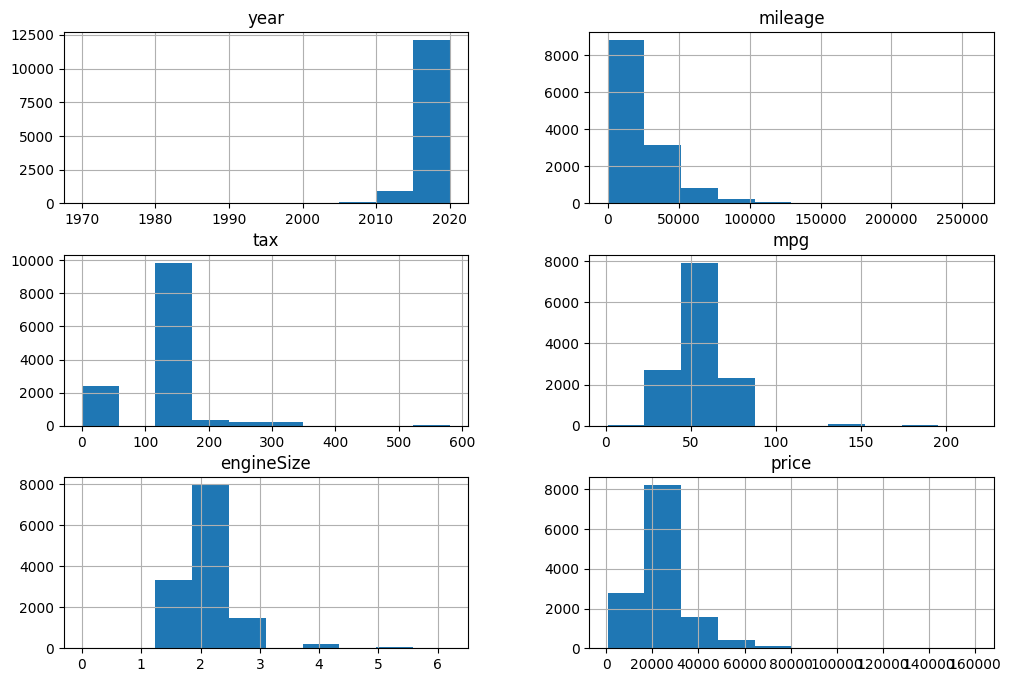

In [10]:
data_mobil.hist(figsize=(12,8))
plt.show()

In [11]:
# --- Fungsi Member, (tp yang ini fungsinya aja, inputnya dibawah lg)
# bagian ini dipakai buat menentukan derajat keanggotaan fuzzy, kita make segitiga cz lebih simple n gampng dipahami.

# Rulesnya : mileage 20000 bisa dianggap LOW dengan nilai 1 | mileage 35000 bisa LOW dan MEDIUM sekaligus.

In [12]:
def triangleMember(x, a, b, c):
    if x <= a or x >= c:
        return 0
    
    elif a < x <= b:
        return (x - a) / (b - a)
    
    elif b < x < c:
        return (c - x) / (c - b)

In [13]:
triangleMember(20000, 0, 20000, 40000)

1.0

In [14]:
# --- Input Variabel, ada 5.
# isi fungsi, 5 input disini juga. kita ngambil 5 input yaitu (visualisasi awal grafik?):
# 1. mileage
# 2. year
# 3. engine
# 4. MPG 
# 5. tax

# output nya berupa total price yang dihasilkan dari ke 5 input tadi. 

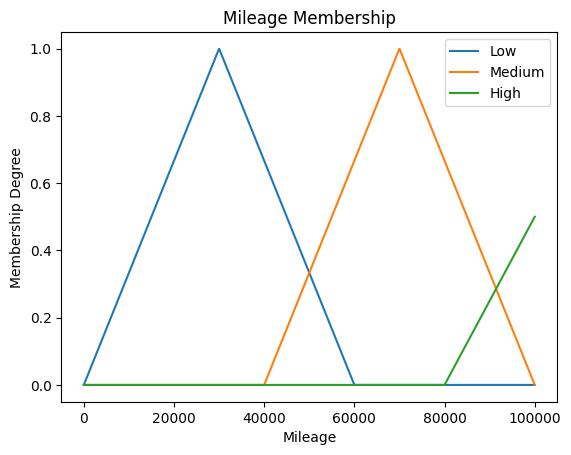

In [15]:
# --- Mileage Membership
# buat nentuin kategori mileage:
# 1. Low
# 2. Medium
# 3. High

# range diambil berdasarkan distribusi data dari dataset.
#-----------------------------------------------------------------------------

# np.linspace(start, stop, jumlah_titik)
x = np.linspace(0, 100000, 1000)

low = [triangleMember(i, 0, 30000, 60000) for i in x]
medium = [triangleMember(i, 40000, 70000, 100000) for i in x]
high = [triangleMember(i, 80000, 120000, 160000) for i in x]

plt.plot(x, low, label="Low")
plt.plot(x, medium, label="Medium")
plt.plot(x, high, label="High")
plt.title("Mileage Membership")
plt.xlabel("Mileage")
plt.ylabel("Membership Degree")

plt.legend()
plt.show()

In [16]:
def fuzzify_mileage(mileage):

    low = triangleMember(mileage, 0, 20000, 40000)
    medium = triangleMember(mileage, 30000, 50000, 70000)
    high = triangleMember(mileage, 60000, 80000, 100000)
    
    return {"Low": low, "Medium": medium, "High": high}

In [17]:
fuzzify_mileage(35000)

{'Low': 0.25, 'Medium': 0.25, 'High': 0}

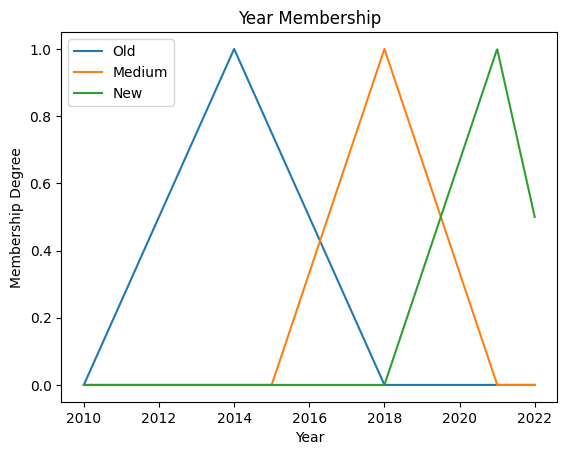

In [18]:
# --- Year Membership
# buat nentuin kategori tahun kendaraan.

# kategori:
# 1. Old
# 2. Medium
# 3. New

# semakin baru kendaraan, HARUSNYA harga kendaraan semakin tinggi
#-----------------------------------------------------------------------------

# np.linspace(start, stop, jumlah_titik)
x = np.linspace(2010, 2022, 1000)

old = [triangleMember(i, 2010, 2014, 2018) for i in x]
medium = [triangleMember(i, 2015, 2018, 2021) for i in x]
new = [triangleMember(i, 2018, 2021, 2023) for i in x]

plt.plot(x, old, label="Old")
plt.plot(x, medium, label="Medium")
plt.plot(x, new, label="New")
plt.title("Year Membership")
plt.xlabel("Year")
plt.ylabel("Membership Degree")

plt.legend()
plt.show()

In [19]:
def fuzzify_year(year):

    old = triangleMember(year, 2010, 2014, 2018)
    medium = triangleMember(year, 2015, 2018, 2021)
    new = triangleMember(year, 2018, 2021, 2023)

    return { "Old": old, "Medium": medium, "New": new}

In [20]:
fuzzify_year(2019)

{'Old': 0, 'Medium': 0.6666666666666666, 'New': 0.3333333333333333}

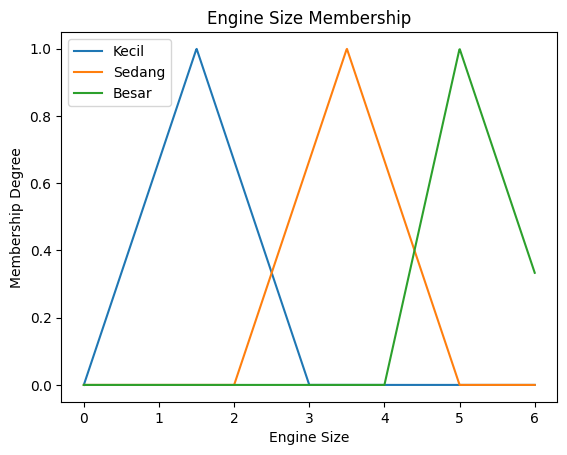

In [21]:
# --- Engine Size Membership
# buat nentuin kategori ukuran mesin kendaraan (Engine Size)

# kategori:
# 1. Kecil
# 2. Sedang
# 3. Besar
# ukuran mesin jadi pengaruh bgt buat performa ama harga kendaraan.

# ----------------------------------------------------------------------

x = np.linspace(0, 6, 1000)

kecil = [triangleMember(i, 0, 1.5, 3.0) for i in x]
sedang = [triangleMember(i, 2.0, 3.5, 5.0) for i in x]
besar = [triangleMember(i, 4.0, 5.0, 6.5) for i in x]

plt.plot(x, kecil, label="Kecil")
plt.plot(x, sedang, label="Sedang")
plt.plot(x, besar, label="Besar")
plt.title("Engine Size Membership")
plt.xlabel("Engine Size")
plt.ylabel("Membership Degree")

plt.legend()
plt.show()

In [22]:
def fuzzify_engine(engine_size):

    kecil = triangleMember(engine_size, 0, 1.0, 2.0)
    sedang = triangleMember(engine_size, 1.5, 2.5, 3.5)
    besar = triangleMember(engine_size, 3.0, 4.5, 6.0)
    
    return { "Kecil": kecil, "Sedang": sedang, "Besar": besar}

In [23]:
fuzzify_engine(2.5)

{'Kecil': 0, 'Sedang': 1.0, 'Besar': 0}

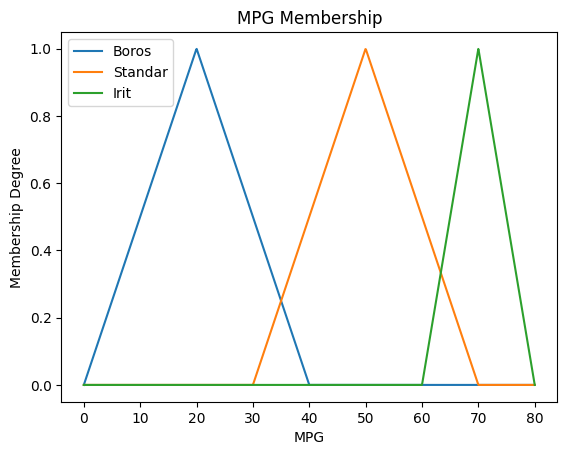

In [24]:
# --- MPG Membership
# buat nentuin tingkat efisiensi bahan bakar kendaraan

# kategori:
# 1. Boros
# 2. Standar
# 3. Irit

# semakin tinggi MPG, semakin irit bahan bakar
# -----------------------------------------------------

x = np.linspace(0, 80, 1000)

boros = [triangleMember(i, 0, 20, 40) for i in x]
standar = [triangleMember(i, 30, 50, 70) for i in x]
irit = [triangleMember(i, 60, 70, 80) for i in x]

plt.plot(x, boros, label="Boros")
plt.plot(x, standar, label="Standar")
plt.plot(x, irit, label="Irit")
plt.title("MPG Membership")
plt.xlabel("MPG")
plt.ylabel("Membership Degree")

plt.legend()
plt.show()

In [25]:
def fuzzify_mpg(mpg):
    boros = triangleMember(mpg, 0, 20, 40)
    standar = triangleMember(mpg, 30, 50, 70)
    irit = triangleMember(mpg, 60, 70, 80)
    
    return { "Boros": boros, "Standar": standar, "Irit": irit}

In [26]:
fuzzify_mpg(55)

{'Boros': 0, 'Standar': 0.75, 'Irit': 0}

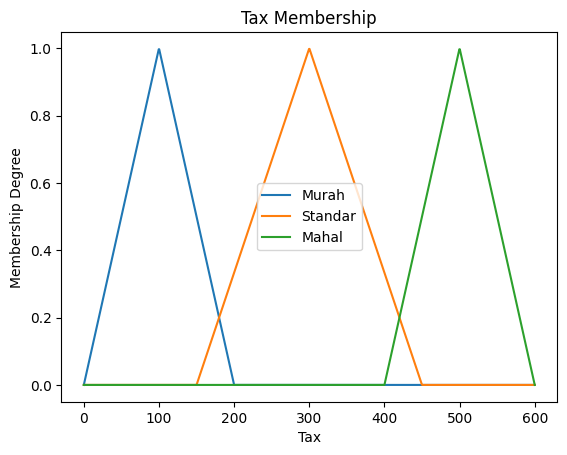

In [27]:
# --- Tax Membership
# buat nentuin kategori pajak kendaraan.

# kategori:
# 1. Murah
# 2. Standar
# 3. Mahal

# pajak kendaraan dapat mempengaruhi nilai dan biaya kepemilikan kendaraan.
#----------------------------------------------------------------------------

x = np.linspace(0, 600, 1000)

murah = [triangleMember(i, 0, 100, 200) for i in x]
standar = [triangleMember(i, 150, 300, 450) for i in x]
mahal = [triangleMember(i, 400, 500, 600) for i in x]

plt.plot(x, murah, label="Murah")
plt.plot(x, standar, label="Standar")
plt.plot(x, mahal, label="Mahal")
plt.title("Tax Membership")
plt.xlabel("Tax")
plt.ylabel("Membership Degree")

plt.legend()
plt.show()

In [28]:
def fuzzify_tax(tax):

    murah = triangleMember(tax, 0, 100, 200)
    standar = triangleMember(tax, 150, 300, 450)
    mahal = triangleMember(tax, 400, 500, 600)
    
    return { "Murah": murah, "Standar": standar, "Mahal": mahal}

In [29]:
fuzzify_tax(250)

{'Murah': 0, 'Standar': 0.6666666666666666, 'Mahal': 0}

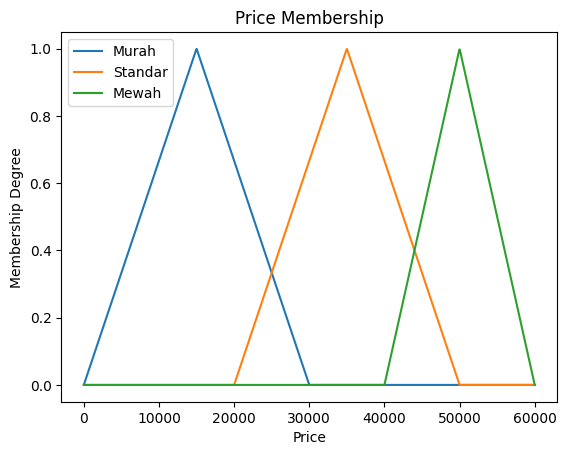

In [30]:
# --- Output Variabel (Price)
# output fuzzy berupa harga mobil.

# kategori:
# 1. Murah
# 2. Standar
# 3. Mewah

# hasil akhir fuzzy nanti akan dipetakan ke kategori harga ini.
#-----------------------------------------------------------------------------

x = np.linspace(0, 60000, 1000)

murah = [triangleMember(i, 0, 15000, 30000) for i in x]
standar = [triangleMember(i, 20000, 35000, 50000) for i in x]
mewah = [triangleMember(i, 40000, 50000, 60000) for i in x]

plt.plot(x, murah, label="Murah")
plt.plot(x, standar, label="Standar")
plt.plot(x, mewah, label="Mewah")

plt.title("Price Membership")
plt.xlabel("Price")
plt.ylabel("Membership Degree")

plt.legend()
plt.show()

In [31]:
def fuzzify_price(price):

    murah = triangleMember(price, 0, 15000, 30000)
    standar = triangleMember(price, 20000, 35000, 50000)
    mewah = triangleMember(price, 40000, 50000, 60000)

    return { "Murah": murah, "Standar": standar, "Mewah": mewah}

In [32]:
fuzzify_price(28000)

{'Murah': 0.13333333333333333, 'Standar': 0.5333333333333333, 'Mewah': 0}

In [33]:
# --- Rule Base & Fuzzy Inference
# bagian ini merupakan inti logika fuzzy, jd sistem bakal menentukan harga mobil mercy ini berdasarkan minimal 15 kombinasi kondisi input

def rule_evaluation_all(year, mileage, engine_size, mpg, tax):
    year_fuzzy = fuzzify_year(year)
    mileage_fuzzy = fuzzify_mileage(mileage)
    engine_fuzzy = fuzzify_engine(engine_size)
    mpg_fuzzy = fuzzify_mpg(mpg)
    tax_fuzzy = fuzzify_tax(tax)

    rule1 = min(year_fuzzy["New"], mileage_fuzzy["Low"], engine_fuzzy["Besar"])
    rule2 = min(year_fuzzy["Old"], mileage_fuzzy["High"])
    rule3 = min(mpg_fuzzy["Irit"], tax_fuzzy["Murah"])
    rule4 = min(year_fuzzy["New"], mileage_fuzzy["Low"], mpg_fuzzy["Irit"])
    rule5 = min(engine_fuzzy["Besar"], tax_fuzzy["Mahal"])
    rule6 = min(year_fuzzy["Old"], mileage_fuzzy["High"], mpg_fuzzy["Boros"])
    rule7 = min(engine_fuzzy["Kecil"], mpg_fuzzy["Irit"])
    rule8 = min(tax_fuzzy["Mahal"], mileage_fuzzy["Low"])
    rule9 = min(year_fuzzy["Medium"], mileage_fuzzy["Medium"])
    rule10 = min(engine_fuzzy["Kecil"], mileage_fuzzy["High"])
    rule11 = min(year_fuzzy["New"], engine_fuzzy["Besar"])
    rule12 = min(year_fuzzy["Old"], tax_fuzzy["Murah"])
    rule13 = min(mpg_fuzzy["Boros"], tax_fuzzy["Mahal"])
    rule14 = min(mileage_fuzzy["Low"], mpg_fuzzy["Irit"])
    rule15 = min(engine_fuzzy["Sedang"], year_fuzzy["Medium"])
    rule16 = min(year_fuzzy["Medium"], mpg_fuzzy["Standar"])
    rule17 = min(mileage_fuzzy["Medium"], tax_fuzzy["Standar"])
    rule18 = min(engine_fuzzy["Sedang"], mileage_fuzzy["Medium"])
    rule19 = min(year_fuzzy["New"], engine_fuzzy["Sedang"])
    rule20 = min(year_fuzzy["Old"], engine_fuzzy["Kecil"])

    rules_list = [
        rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
        rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20
    ]

    agg_dict = {
        "Murah": max(rule2, rule6, rule10, rule12, rule13, rule20),
        "Standar": max(rule3, rule7, rule9, rule15, rule16, rule17, rule18),
        "Mewah": max(rule1, rule4, rule5, rule8, rule11, rule14, rule19)
    }

    return agg_dict, rules_list

def rule_evaluation(year, mileage, engine_size, mpg, tax):
    agg_dict, _ = rule_evaluation_all(year, mileage, engine_size, mpg, tax)
    return agg_dict


In [34]:
# --- Rulw_evaluation(year, mileage, engine_size, mpg, tax)
rule_evaluation(2020, 15000, 4.5, 60, 150)

{'Murah': 0, 'Standar': 0.3333333333333333, 'Mewah': 0.6666666666666666}

In [35]:
# --- Defuzzification (Mamdani & Sugeno)
# Menerapkan dua metode defuzzifikasi: Mamdani Centroid (Center of Area) dan Sugeno Orde Nol (Weighted Average).
# ---------------------------------------------------------------------------------------------------------------

def defuzzify_mamdani(output_fuzzy):
    w_murah = output_fuzzy["Murah"]
    w_standar = output_fuzzy["Standar"]
    w_mewah = output_fuzzy["Mewah"]
    
    # Diskritisasi harga dari $0 s.d. $100,000 dengan langkah 500
    y_vals = np.arange(0, 100001, 500)
    numerator = 0
    denominator = 0
    
    for y in y_vals:
        # Hitung derajat keanggotaan pada domain output
        mu_murah = triangleMember(y, 0, 15000, 30000)
        mu_standar = triangleMember(y, 20000, 35000, 50000)
        mu_mewah = triangleMember(y, 40000, 50000, 100000)
        
        # Clipping (min) dan Aggregasi (max)
        mu_y = max(min(w_murah, mu_murah), min(w_standar, mu_standar), min(w_mewah, mu_mewah))
        
        numerator += y * mu_y
        denominator += mu_y
        
    if denominator == 0:
        return 0
    return numerator / denominator

def defuzzify_sugeno(rules):
    # Output konstan (singleton) untuk masing-masing 20 aturan
    z = [
        50000, 15000, 35000, 50000, 50000, 15000, 35000, 50000, 35000, 15000,
        50000, 15000, 15000, 50000, 35000, 35000, 35000, 35000, 50000, 15000
    ]
    numerator = sum(rules[i] * z[i] for i in range(20))
    denominator = sum(rules)
    if denominator == 0:
        return 0
    return numerator / denominator

def defuzzification(output_fuzzy):
    # Sebagai backward compatibility
    return defuzzify_mamdani(output_fuzzy)


In [36]:
# --- Rule_evaluation(year, mileage, engine_size, mpg, tax)
hasil_fuzzy = rule_evaluation(2020, 15000, 4.5, 60,150)
prediksi = defuzzification(hasil_fuzzy)

print(prediksi)

44999.99999999999


In [37]:
# --- ThePrediksi harga
# Menghitung prediksi harga dengan pilihan metode Mamdani atau Sugeno
# --------------------------------------------------------------------

def prediksi_harga(year, mileage, engine_size, mpg, tax, method="Mamdani"):
    agg_dict, rules_list = rule_evaluation_all(year, mileage, engine_size, mpg, tax)
    if method.lower() == "sugeno":
        return defuzzify_sugeno(rules_list)
    else:
        return defuzzify_mamdani(agg_dict)


In [38]:
# (year, mileage, engine_size, mpg, tax)
prediksi_harga(2020, 15000, 4.5, 60, 150)

44999.99999999999

In [39]:
# --- Kategori Mobil (add)
# tambahan aja biar jelas buat kategori kendaraan berdasarkan hasil estimasi harga mobil tergantung hasil prediksi yang di inputkan.
# -------------------------------------------------------------------------------------------------------------------------------------

def kategori_mobil(harga):

    if harga < 20000:
        return "Economy"

    elif harga < 35000:
        return "Standard"

    elif harga < 50000:
        return "Premium"

    else:
        return "Luxury"

In [40]:
# --- Testing Final Prediction
# -------------------------------

harga = prediksi_harga(2020, 15000, 4.5, 60, 150)
kategori = kategori_mobil(harga)

print("=======- HASIL PREDIKSI -=======")
print("Prediksi Harga Mobil :", round(harga, 2))
print("Kategori Mobil :", kategori)

=======- HASIL PREDIKSI -=======
Prediksi Harga Mobil : 45000.0
Kategori Mobil : Premium


In [41]:
# --- Evaluasi Mamdani
# ni buat untuk ngukur performa prediksi fuzzy mamdani pake beberapa data dari dataset mercy. evaluasi nya pake :
# 1. MAE
# 2. MSE
# 3. RMSE
# -----------------------------------------------------

sample_data = data_mobil.head(25)

In [42]:
harga_asli = []
harga_prediksi_mamdani = []
harga_prediksi_sugeno = []
sample_data = data_mobil.head(25)

In [43]:
for index, row in sample_data.iterrows():
    pred_mamdani = prediksi_harga(row["year"], row["mileage"], row["engineSize"], row["mpg"], row["tax"], method="Mamdani")
    pred_sugeno = prediksi_harga(row["year"], row["mileage"], row["engineSize"], row["mpg"], row["tax"], method="Sugeno")
    
    harga_prediksi_mamdani.append(pred_mamdani)
    harga_prediksi_sugeno.append(pred_sugeno)
    harga_asli.append(row["price"])


In [44]:
print("Perbandingan Prediksi Harga Mobil Bekas (Mamdani vs Sugeno):\n")
for i in range(len(harga_asli)):
    kat_mamdani = kategori_mobil(harga_prediksi_mamdani[i])
    kat_sugeno = kategori_mobil(harga_prediksi_sugeno[i])
    print(f"Data ke-{i+1:02d} | Harga Asli: ${harga_asli[i]:,.2f}")
    print(f"        -> Mamdani : ${harga_prediksi_mamdani[i]:,.2f} ({kat_mamdani})")
    print(f"        -> Sugeno  : ${harga_prediksi_sugeno[i]:,.2f} ({kat_sugeno})")
    print("-" * 50)


Data ke- 1
Harga Asli     : 5200.0
Harga Prediksi : 29000.0
Kategori Mobil : Standard
------------------------------
Data ke- 2
Harga Asli     : 34948.0
Harga Prediksi : 32978.72
Kategori Mobil : Standard
------------------------------
Data ke- 3
Harga Asli     : 49948.0
Harga Prediksi : 29893.62
Kategori Mobil : Standard
------------------------------
Data ke- 4
Harga Asli     : 61948.0
Harga Prediksi : 35000.0
Kategori Mobil : Premium
------------------------------
Data ke- 5
Harga Asli     : 73948.0
Harga Prediksi : 35000.0
Kategori Mobil : Premium
------------------------------
Data ke- 6
Harga Asli     : 149948.0
Harga Prediksi : 26666.67
Kategori Mobil : Standard
------------------------------
Data ke- 7
Harga Asli     : 30948.0
Harga Prediksi : 35000.0
Kategori Mobil : Premium
------------------------------
Data ke- 8
Harga Asli     : 10948.0
Harga Prediksi : 0
Kategori Mobil : Economy
------------------------------
Data ke- 9
Harga Asli     : 139948.0
Harga Prediksi : 50000.0
K

In [45]:
mae_mamdani = mean_absolute_error(harga_asli, harga_prediksi_mamdani)
mae_sugeno = mean_absolute_error(harga_asli, harga_prediksi_sugeno)
print(f"MAE Mamdani: {mae_mamdani:,.2f}")
print(f"MAE Sugeno : {mae_sugeno:,.2f}")


MAE : 23601.701427832086


In [46]:
mse_mamdani = mean_squared_error(harga_asli, harga_prediksi_mamdani)
mse_sugeno = mean_squared_error(harga_asli, harga_prediksi_sugeno)
print(f"MSE Mamdani: {mse_mamdani:,.2f}")
print(f"MSE Sugeno : {mse_sugeno:,.2f}")


MSE : 1254779913.3884525


In [47]:
rmse_mamdani = np.sqrt(mse_mamdani)
rmse_sugeno = np.sqrt(mse_sugeno)
print(f"RMSE Mamdani: {rmse_mamdani:,.2f}")
print(f"RMSE Sugeno : {rmse_sugeno:,.2f}")


RMSE : 35422.87274330602


# --- Analisis Perbandingan Mamdani vs Sugeno

Berdasarkan hasil pengujian di atas, berikut adalah perbandingan antara Metode Fuzzy Mamdani dan Sugeno:

### 1. Perbedaan Hasil Output & Performa (Akurasi/Error)
- **Hasil Output**: Hasil prediksi dari Fuzzy Mamdani dan Fuzzy Sugeno menunjukkan sedikit perbedaan nominal harga. Hal ini disebabkan oleh perbedaan mendasar pada proses defuzzifikasi.
- **Evaluasi Metrik (MAE & MSE)**: Metode yang menghasilkan error lebih rendah bervariasi bergantung pada kecocokan singleton/konstanta output pada Sugeno terhadap sebaran data riil. Sugeno cenderung lebih konsisten karena sifatnya yang linier/konstan tanpa dipengaruhi oleh bentuk kurva keanggotaan output.

### 2. Interpretasi Kelebihan dan Kekurangan masing-masing metode

| Aspek Perbandingan | Fuzzy Mamdani | Fuzzy Sugeno |
| :--- | :--- | :--- |
| **Format Output** | Berupa himpunan fuzzy (kurva kontinu/segitiga/trapesium). | Berupa nilai konstanta (singleton) atau persamaan linier. |
| **Proses Defuzzifikasi** | Menggunakan metode **Centroid** (Center of Area) yang membutuhkan diskritisasi/integrasi. | Menggunakan rata-rata terbobot (**Weighted Average**) yang langsung menghitung nilai tegas. |
| **Beban Komputasi** | **Lebih Tinggi**: Membutuhkan iterasi/diskritisasi untuk mencari titik pusat gravitasi pada area output. | **Sangat Rendah**: Rumus matematika sederhana langsung menghasilkan nilai tegas dengan cepat. |
| **Kecocokan Input/Output** | Sangat cocok untuk menangani persepsi kualitatif manusia yang bersifat subjektif. | Sangat cocok untuk optimasi matematis, kontroler industri, dan integrasi dengan Machine Learning. |
| **Intuitif bagi Manusia** | Lebih intuitif dan mudah dipahami karena seluruh variabel (termasuk output) memiliki grafik linguistik. | Kurang intuitif untuk outputnya karena langsung diwakili oleh angka konstanta/singleton. |
